
### *[Week 3]* **Assignment 1**
*Name: Ojasvi Chandel\
Enrollment number: 04401022025\
Course: B.Tech(ECE)*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

---
## Part A: Understanding the Dataset

In [ ]:
# Q1. Dataset Overview
df = pd.read_csv('agriculture_yield_dataset.csv')

print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print()
print('Column names:', df.columns.tolist())
print()
print('First 10 records:')
df.head(10)

Number of rows: 1500
Number of columns: 8

Column names: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [ ]:
# Q2. Data Types and Missing Values
print('Data types of each column:')
print(df.dtypes)
print()

print('Missing values in each column:')
print(df.isnull().sum())
print()

print('Total missing values:', df.isnull().sum().sum())

Data types of each column:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values in each column:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Total missing values: 0


In [ ]:
# Q3. Descriptive Statistics
summary = df.describe()
print(summary)
print()

highest_mean = summary.loc['mean'].idxmax()
highest_std = summary.loc['std'].idxmax()

print('Feature with highest mean value:', highest_mean)
print('Feature with highest standard deviation:', highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

---
## Part B: Exploratory Data Analysis (EDA)

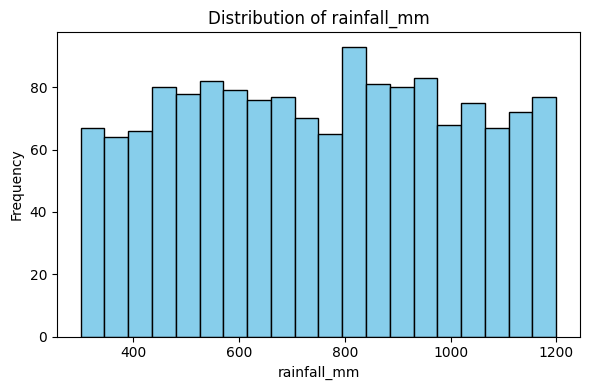

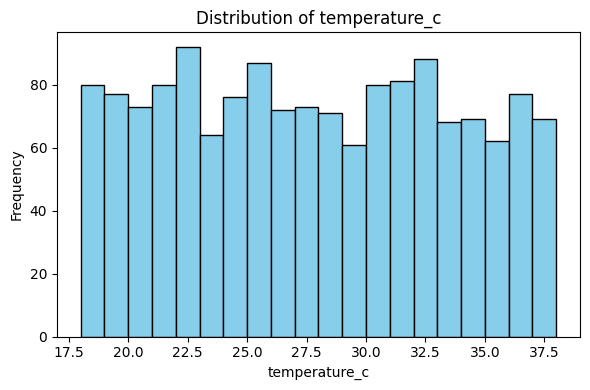

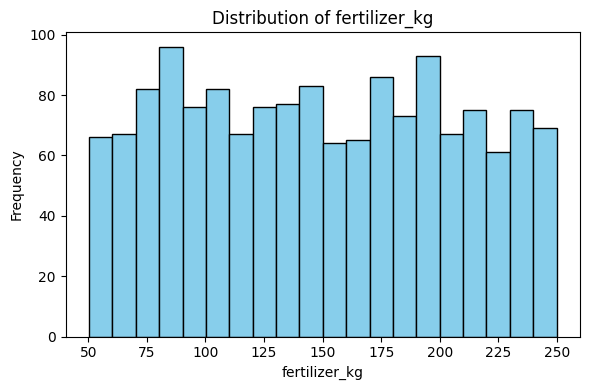

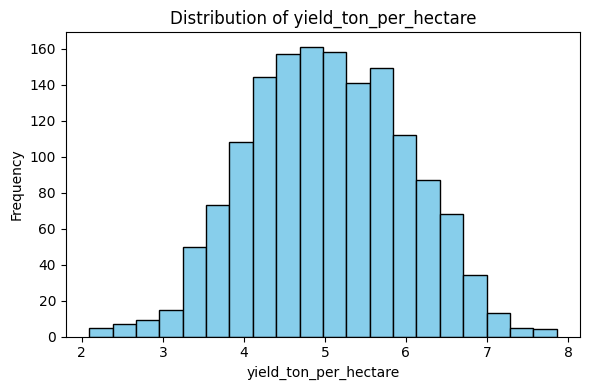

In [ ]:
# Q4. Distribution Analysis (Histograms)
columns_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

for col in columns_to_plot:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

**Observations:**
- `rainfall_mm`: ranges roughly between 500–1200mm, fairly spread out across the range.
- `temperature_c`: spread across a wide range (roughly 18°C–37°C), no extreme skew.
- `fertilizer_kg`: usage spread between about 90–250 kg, fairly even distribution.
- `yield_ton_per_hectare`: clusters mostly between 4 and 7 tons/hectare, looks roughly bell-shaped.

Number of records per crop type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


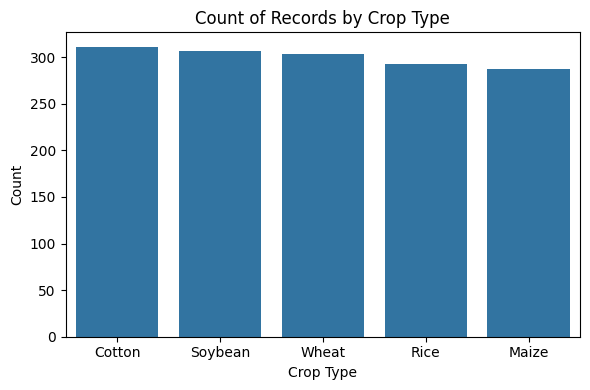


Most frequent crop type: Cotton


In [ ]:
# Q5. Crop Type Analysis
crop_counts = df['crop_type'].value_counts()
print('Number of records per crop type:')
print(crop_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df, order=crop_counts.index)
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print()
print('Most frequent crop type:', crop_counts.idxmax())

Frequency of each soil type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


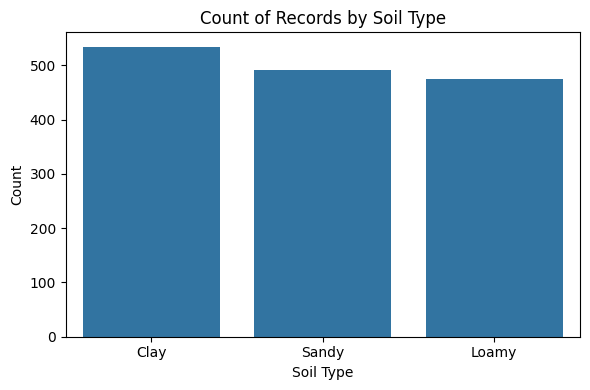


Most common soil type: Clay


In [ ]:
# Q6. Soil Type Analysis
soil_counts = df['soil_type'].value_counts()
print('Frequency of each soil type:')
print(soil_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df, order=soil_counts.index)
plt.title('Count of Records by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print()
print('Most common soil type:', soil_counts.idxmax())

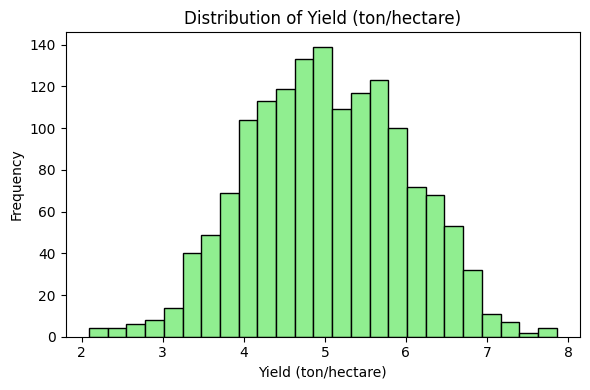

Skewness: -0.001169711222739871


In [ ]:
# Q7. Yield Distribution
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=25, color='lightgreen', edgecolor='black')
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Skewness:', df['yield_ton_per_hectare'].skew())

**Answer:** The distribution looks approximately normal (roughly bell-shaped, centered around the mean), with skewness close to 0. There don't appear to be extreme outliers — values stay within a reasonable, continuous range without isolated extreme spikes.

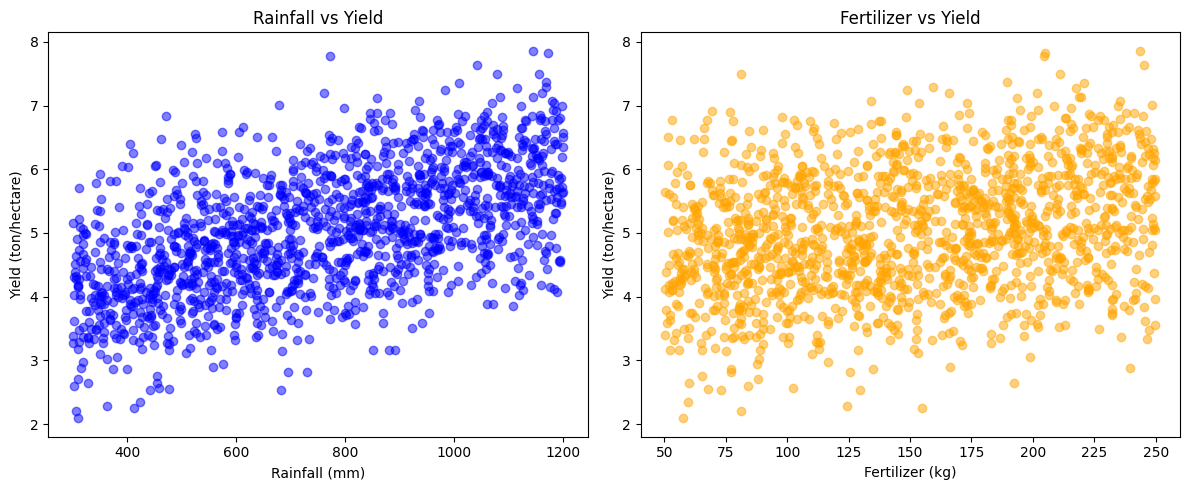

Correlation - rainfall vs yield: 0.5537042408932247
Correlation - fertilizer vs yield: 0.27804258886930494


In [ ]:
# Q8. Scatter Plot Analysis
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.5, color='blue')
axes[0].set_title('Rainfall vs Yield')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (ton/hectare)')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.5, color='orange')
axes[1].set_title('Fertilizer vs Yield')
axes[1].set_xlabel('Fertilizer (kg)')
axes[1].set_ylabel('Yield (ton/hectare)')

plt.tight_layout()
plt.show()

print('Correlation - rainfall vs yield:', df['rainfall_mm'].corr(df['yield_ton_per_hectare']))
print('Correlation - fertilizer vs yield:', df['fertilizer_kg'].corr(df['yield_ton_per_hectare']))

**Answer:** Whichever correlation value printed above is higher (closer to ±1) is the feature with the stronger relationship to yield — check the printed numbers and name that one.

Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412    

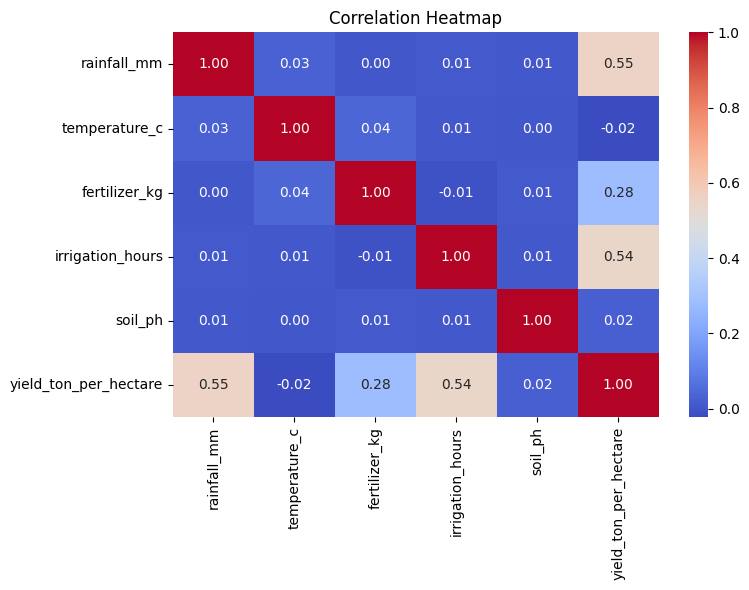


Top 3 features most correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [ ]:
# Q9. Correlation Analysis
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

print('Correlation Matrix:')
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

top_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print()
print('Top 3 features most correlated with yield:')
print(top_corr.head(3))

In [ ]:
# Q10. Group-Based Analysis
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print('Average yield by crop type:')
print(avg_yield_crop)
print()
print('Average yield by soil type:')
print(avg_yield_soil)

print()
print('Crop type with highest average yield:', avg_yield_crop.idxmax())
print('Soil type with highest average yield:', avg_yield_soil.idxmax())

Average yield by crop type:
crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Average yield by soil type:
soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop type with highest average yield: Rice
Soil type with highest average yield: Loamy


---
## Part C: Data Preparation

In [ ]:
# Q11. Feature Encoding (One-Hot Encoding)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print()
print('First five rows of transformed dataset:')
df_encoded.head()

Categorical columns: ['crop_type', 'soil_type']

First five rows of transformed dataset:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [ ]:
# Q12. Feature Selection
X = df_encoded.drop(columns=['yield_ton_per_hectare'])
y = df_encoded['yield_ton_per_hectare']

print('Target variable: yield_ton_per_hectare')
print()
print('Input feature columns:', X.columns.tolist())

Target variable: yield_ton_per_hectare

Input feature columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']


---
## Part D: Machine Learning

In [ ]:
# Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (1200, 11)
Shape of X_test: (300, 11)
Shape of y_train: (1200,)
Shape of y_test: (300,)


In [ ]:
# Q14. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

coefficients = pd.Series(lr_model.coef_, index=X.columns)
print('Model Coefficients:')
print(coefficients)
print()
print('Model Intercept:', lr_model.intercept_)
print()
print('Feature with highest positive coefficient:', coefficients.idxmax())

Model Coefficients:
rainfall_mm          0.002035
temperature_c       -0.009175
fertilizer_kg        0.004978
irrigation_hours     0.198327
soil_ph              0.004901
crop_type_Maize      0.238931
crop_type_Rice       0.863993
crop_type_Soybean    0.481719
crop_type_Wheat      0.348474
soil_type_Loamy      0.302974
soil_type_Sandy     -0.490933
dtype: float64

Model Intercept: 1.587132027736121

Feature with highest positive coefficient: crop_type_Rice
